In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data=pd.read_csv("smart_healthcare_dataset.csv")
data.head()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


In [3]:
data.isnull().sum()

age                  0
gender               0
bmi                  0
exercise_level       0
smoking              0
alcohol              0
blood_pressure       0
cholesterol          0
glucose              0
fatigue              0
chest_pain           0
dizziness            0
heart_disease        0
diabetes             0
stroke               0
health_risk_score    0
dtype: int64

In [4]:
data['gender']=data['gender'].map({'Male':1,'Female':0})

In [5]:
data.head()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,1,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,0,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,0,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,0,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,0,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


In [6]:
for i in data.columns:
    print(data[i].unique())

[56 69 46 32 60 25 78 38 75 36 40 28 41 70 53 57 20 39 19 61 47 55 77 50
 29 42 66 44 76 59 45 33 79 64 68 72 74 54 24 26 35 21 31 67 43 37 52 34
 23 71 51 27 48 65 62 58 18 22 30 49 73 63]
[1 0]
[22.6 28.2 25.1 18.  20.1 26.  24.6 22.1 28.5 22.4 35.8 17.9 15.7 28.9
 21.6 23.4 21.1 23.7 33.  29.  29.3 19.2 15.  21.  29.8 27.6 23.9 24.9
 28.8 16.9 26.5 29.7 22.9 39.1 24.5 27.  21.3 25.9 27.3 19.9 32.3 27.2
 23.8 28.7 26.4 20.2 26.6 20.  21.8 19.1 30.3 27.9 21.5 17.3 24.3 22.8
 25.6 23.2 23.1 23.5 33.4 15.4 31.6 25.4 30.7 19.5 32.1 24.4 26.1 31.2
 19.8 28.  17.5 31.8 29.4 24.7 26.2 24.  32.8 33.1 15.5 22.7 22.  20.6
 34.  33.3 25.  30.4 31.4 26.7 29.5 28.1 33.2 26.9 17.4 30.6 30.  27.4
 15.8 29.9 21.4 24.2 24.1 27.5 34.1 23.3 22.5 20.8 26.8 36.7 26.3 30.5
 17.2 21.9 20.7 19.4 22.3 25.2 27.8 34.3 16.  29.2 30.9 18.1 27.1 17.1
 32.2 25.8 36.  30.2 23.6 29.6 18.2 19.6 35.5 30.8 32.5 17.6 31.  19.7
 18.5 17.  16.3 23.  31.1 21.2 33.5 28.4 16.7 34.7 30.1 21.7 24.8 20.3
 22.2 16.6 28.6 20.9 25

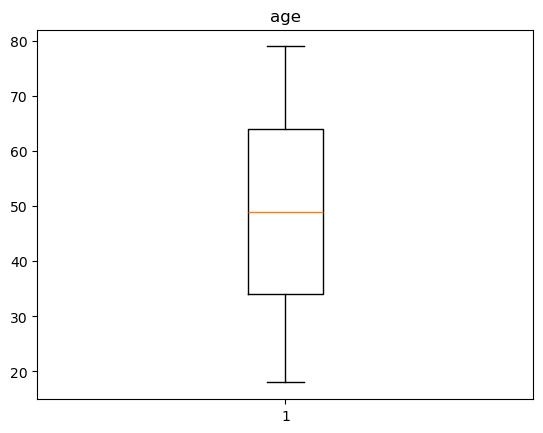

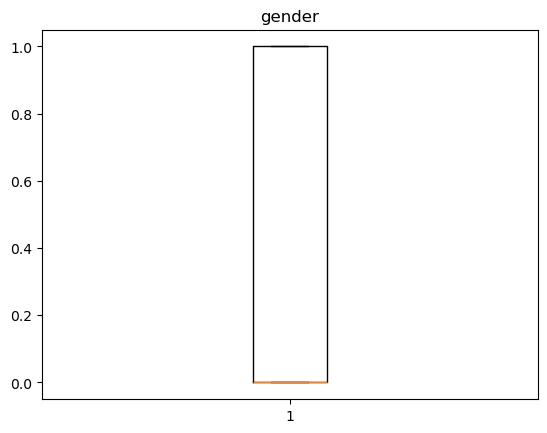

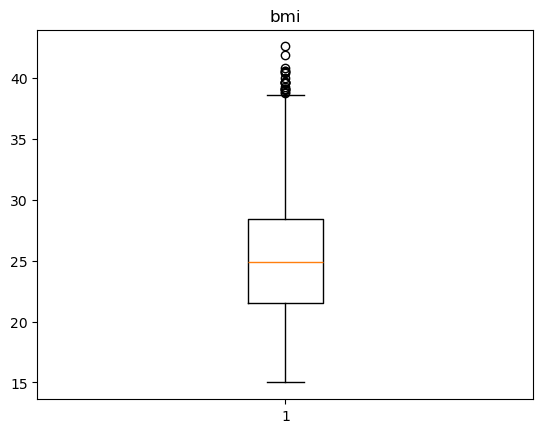

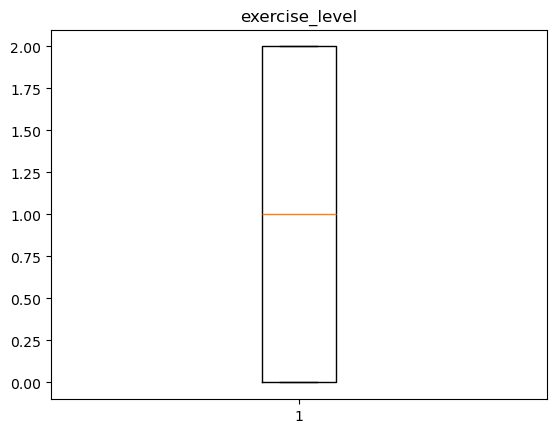

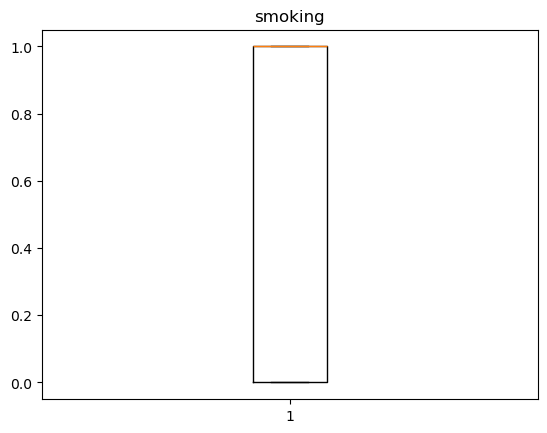

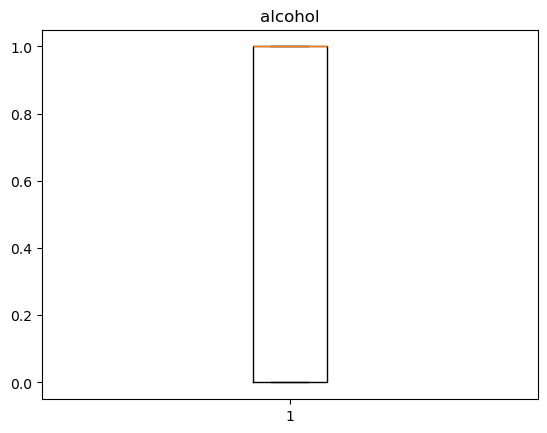

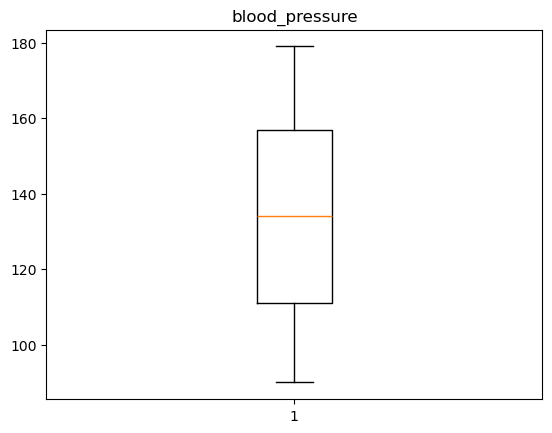

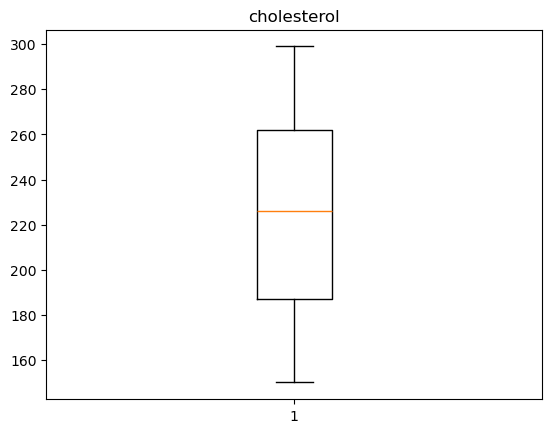

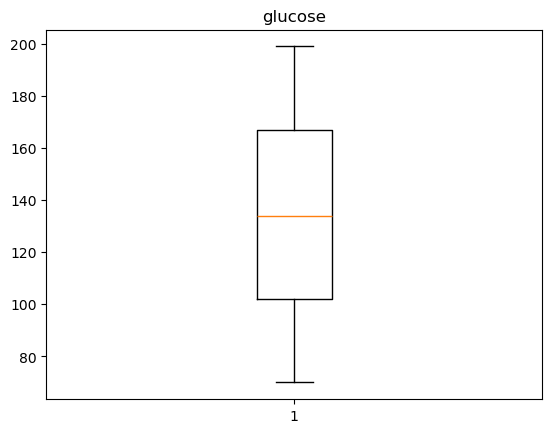

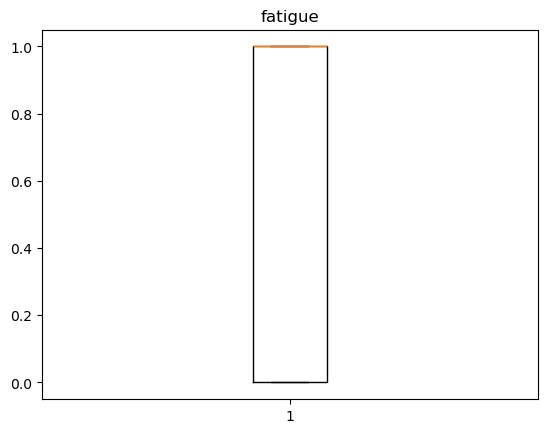

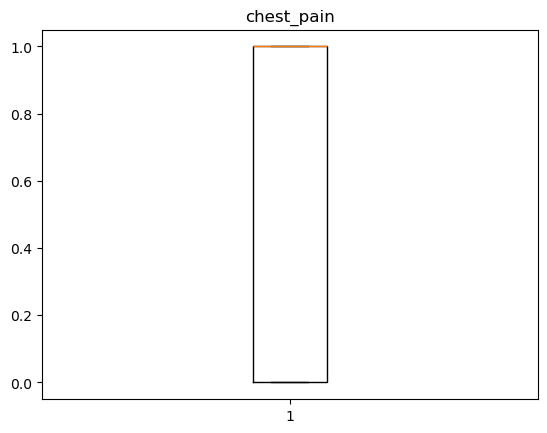

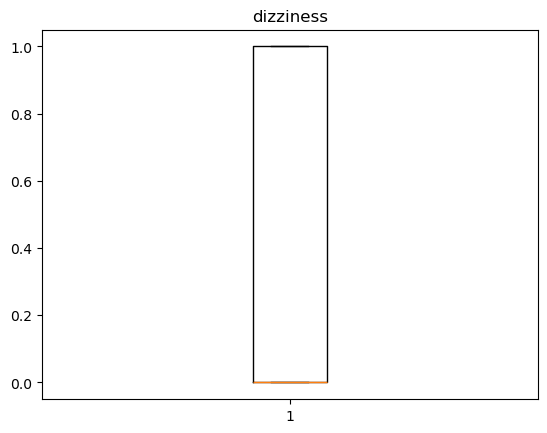

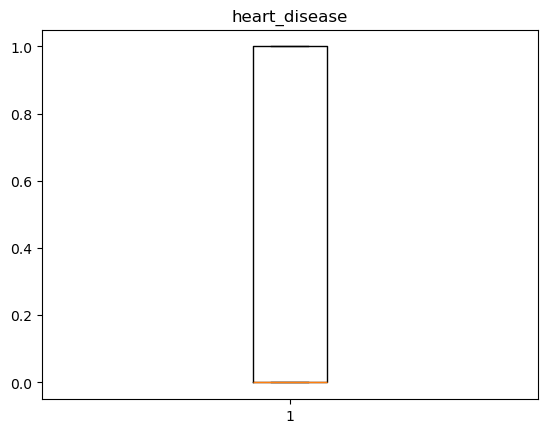

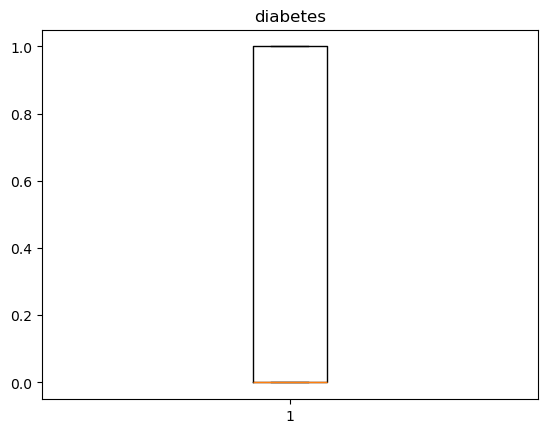

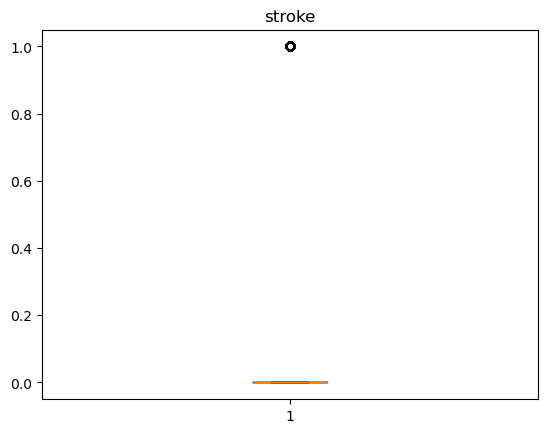

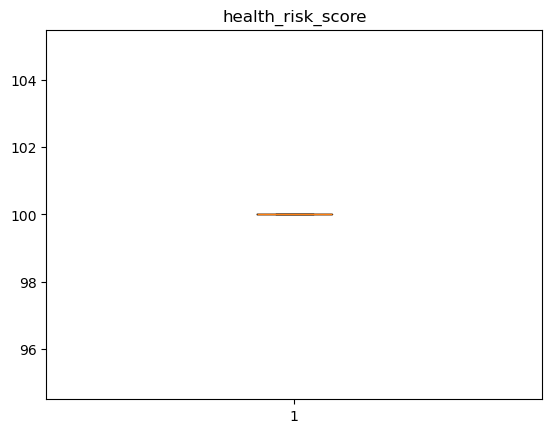

In [7]:
for i in data.columns:
    plt.figure()
    plt.boxplot(data[i])
    plt.title(i)
    plt.show()

In [8]:
data['stroke'].unique()

array([0, 1])

In [9]:
data['fatigue'].value_counts()

fatigue
1    2576
0    2424
Name: count, dtype: int64

In [10]:
x=data.drop('fatigue',axis=1)
y=data['fatigue']

In [11]:
x.head()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,1,22.6,2,1,1,169,225,74,1,0,0,0,0,100.0
1,69,0,28.2,0,1,1,136,230,198,1,0,1,1,1,100.0
2,46,0,25.1,1,0,1,142,221,89,1,1,0,0,0,100.0
3,32,0,18.0,0,0,1,173,296,152,0,0,0,0,0,100.0
4,60,0,20.1,2,1,0,130,292,133,1,1,0,1,0,100.0


In [12]:
y.head()

0    0
1    0
2    0
3    1
4    1
Name: fatigue, dtype: int64

In [13]:
data['stroke'].value_counts()

stroke
0    3757
1    1243
Name: count, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=100)

In [15]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale features AFTER train_test_split to avoid data leakage
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Use optimized SVM parameters
model = SVC(kernel='rbf', C=10, gamma='scale', random_state=10, probability=True)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

In [16]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print("train Accuracy:", accuracy_score(y_train,model.predict(x_train)))
print("test Accuracy:", accuracy_score(y_test,y_pred))


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


train Accuracy: 0.48342857142857143
test Accuracy: 0.482


In [1]:
## Train the Model
#Split the data, fit the SVM, and check accuracy.
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.3, random_state=100)
model = SVC(kernel='rbf', C=10, gamma='scale', random_state=10, probability=True)
model.fit(train_x, train_y)
train_pred = model.predict(train_x)
test_pred = model.predict(test_x)
print("Train Accuracy:", accuracy_score(train_y, train_pred))
print("Test Accuracy:", accuracy_score(test_y, test_pred))

NameError: name 'train_test_split' is not defined

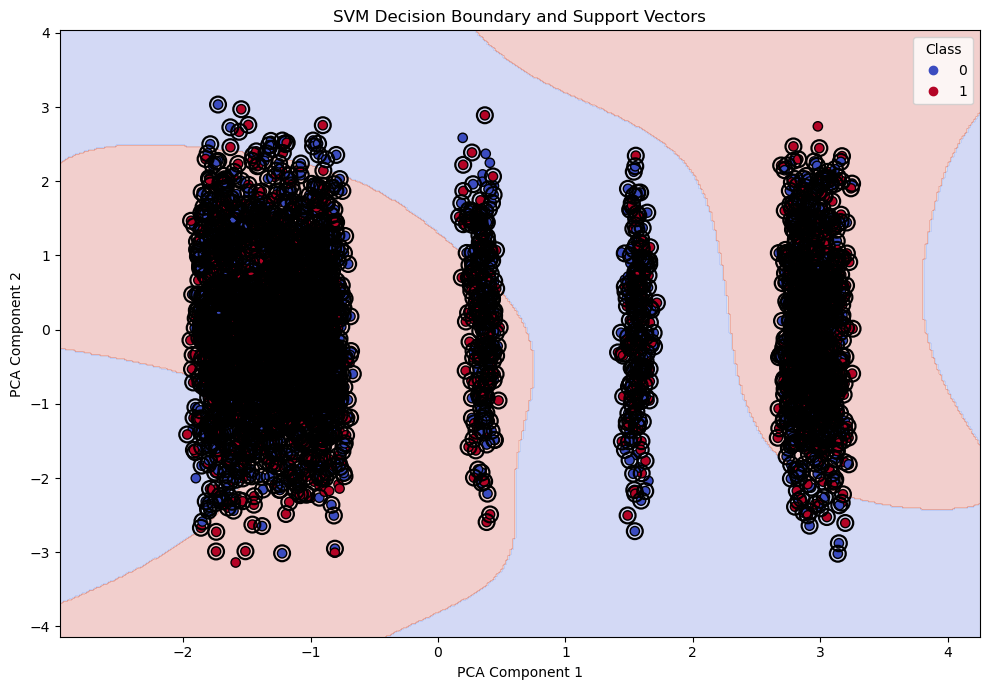

In [19]:
import numpy as np
import matplotlib.pyplot as plt

x_min, x_max = x_train_pca[:, 0].min() - 1, x_train_pca[:, 0].max() + 1
y_min, y_max = x_train_pca[:, 1].min() - 1, x_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = model_pca.predict(grid).reshape(xx.shape)

support_vectors = model_pca.support_vectors_

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
scatter = plt.scatter(
    x_train_pca[:, 0],
    x_train_pca[:, 1],
    c=y_train,
    cmap='coolwarm',
    edgecolor='k',
    s=45,
)
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=130,
    facecolors='none',
    edgecolors='black',
    linewidths=1.6,
    label='Support vectors',
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('SVM Decision Boundary and Support Vectors')
plt.legend(*scatter.legend_elements(), title='Class', loc='upper right')
plt.tight_layout()
plt.show()

## Decision Boundary

This plot shows the SVM boundary in PCA space and marks the support vectors.